In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data = pd.read_csv('/content/drive/MyDrive/netflix_customer_churn.csv')
data.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
data.isna().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


In [4]:
data.shape

(5000, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [6]:
import matplotlib.pyplot as plt

EDA

EDA for Numerical Features (data_num):


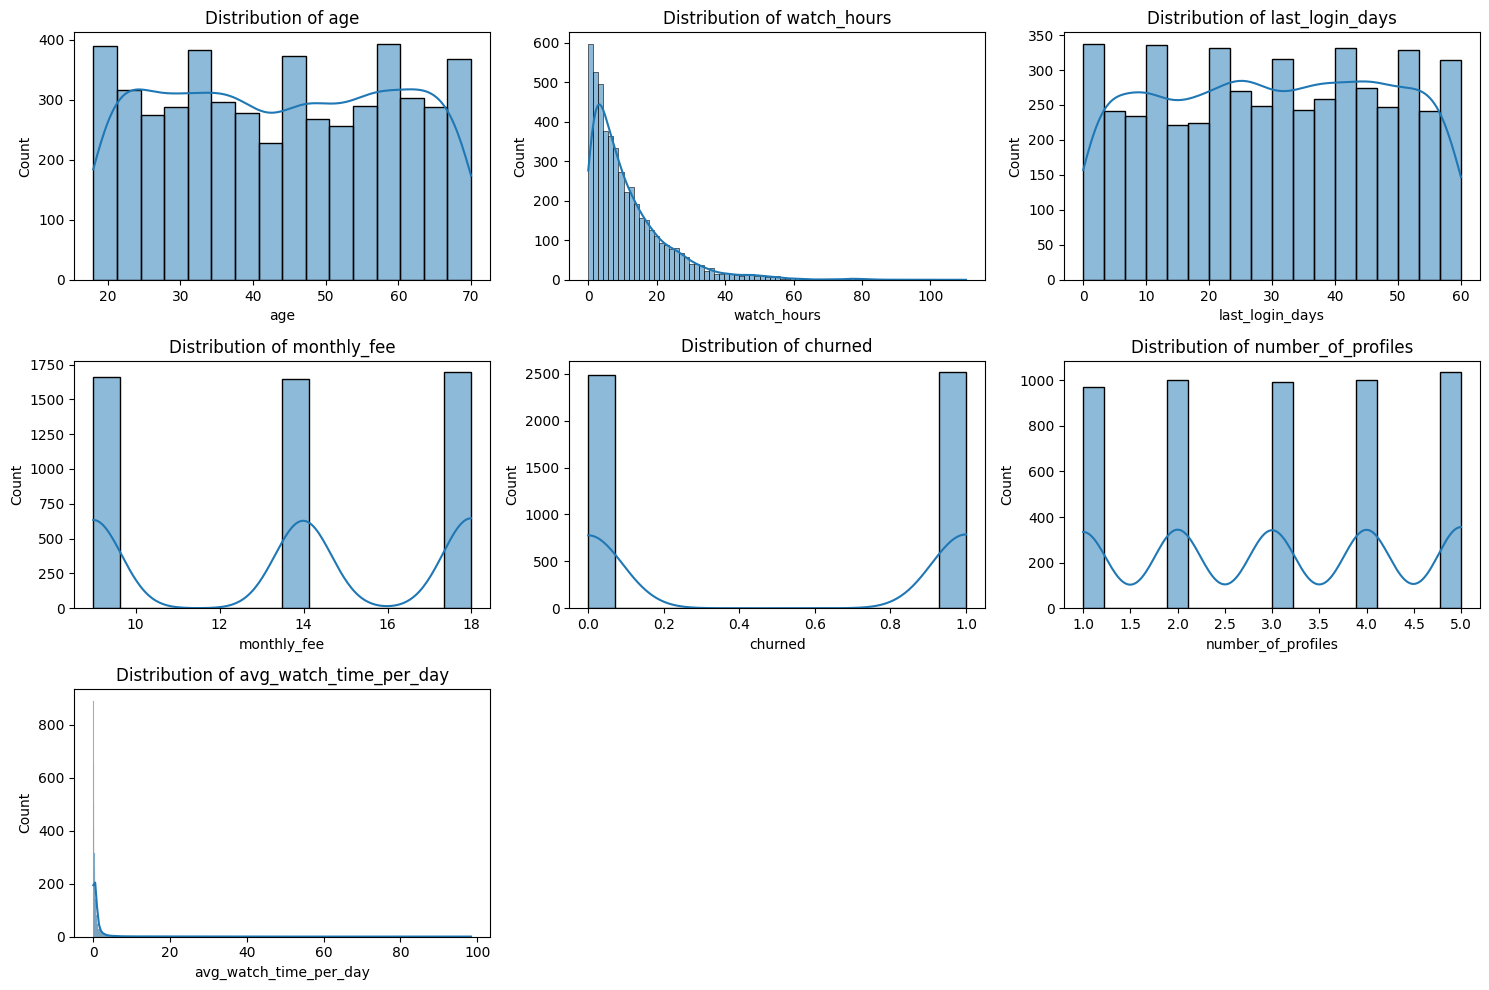

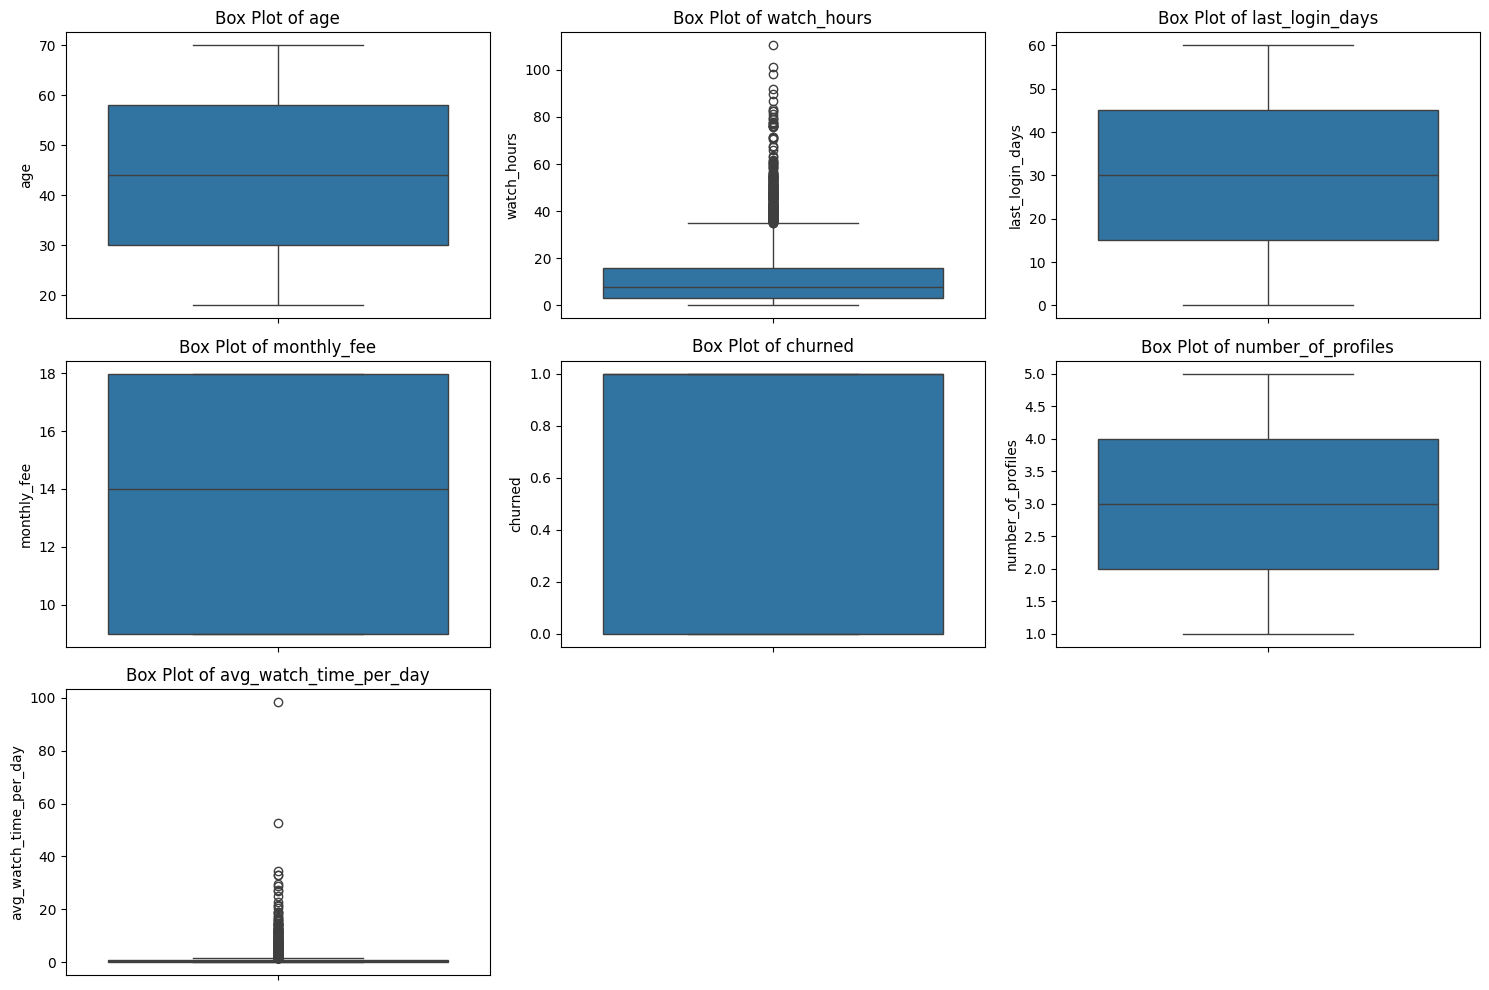

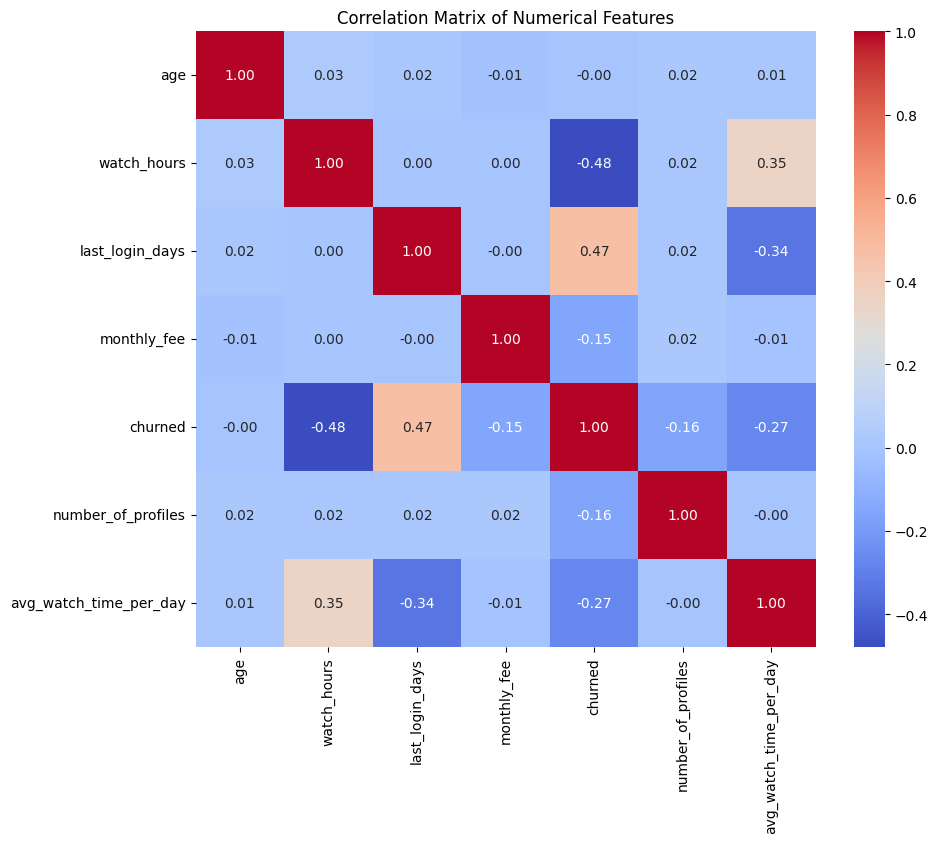


EDA for Categorical Features (data_cat):


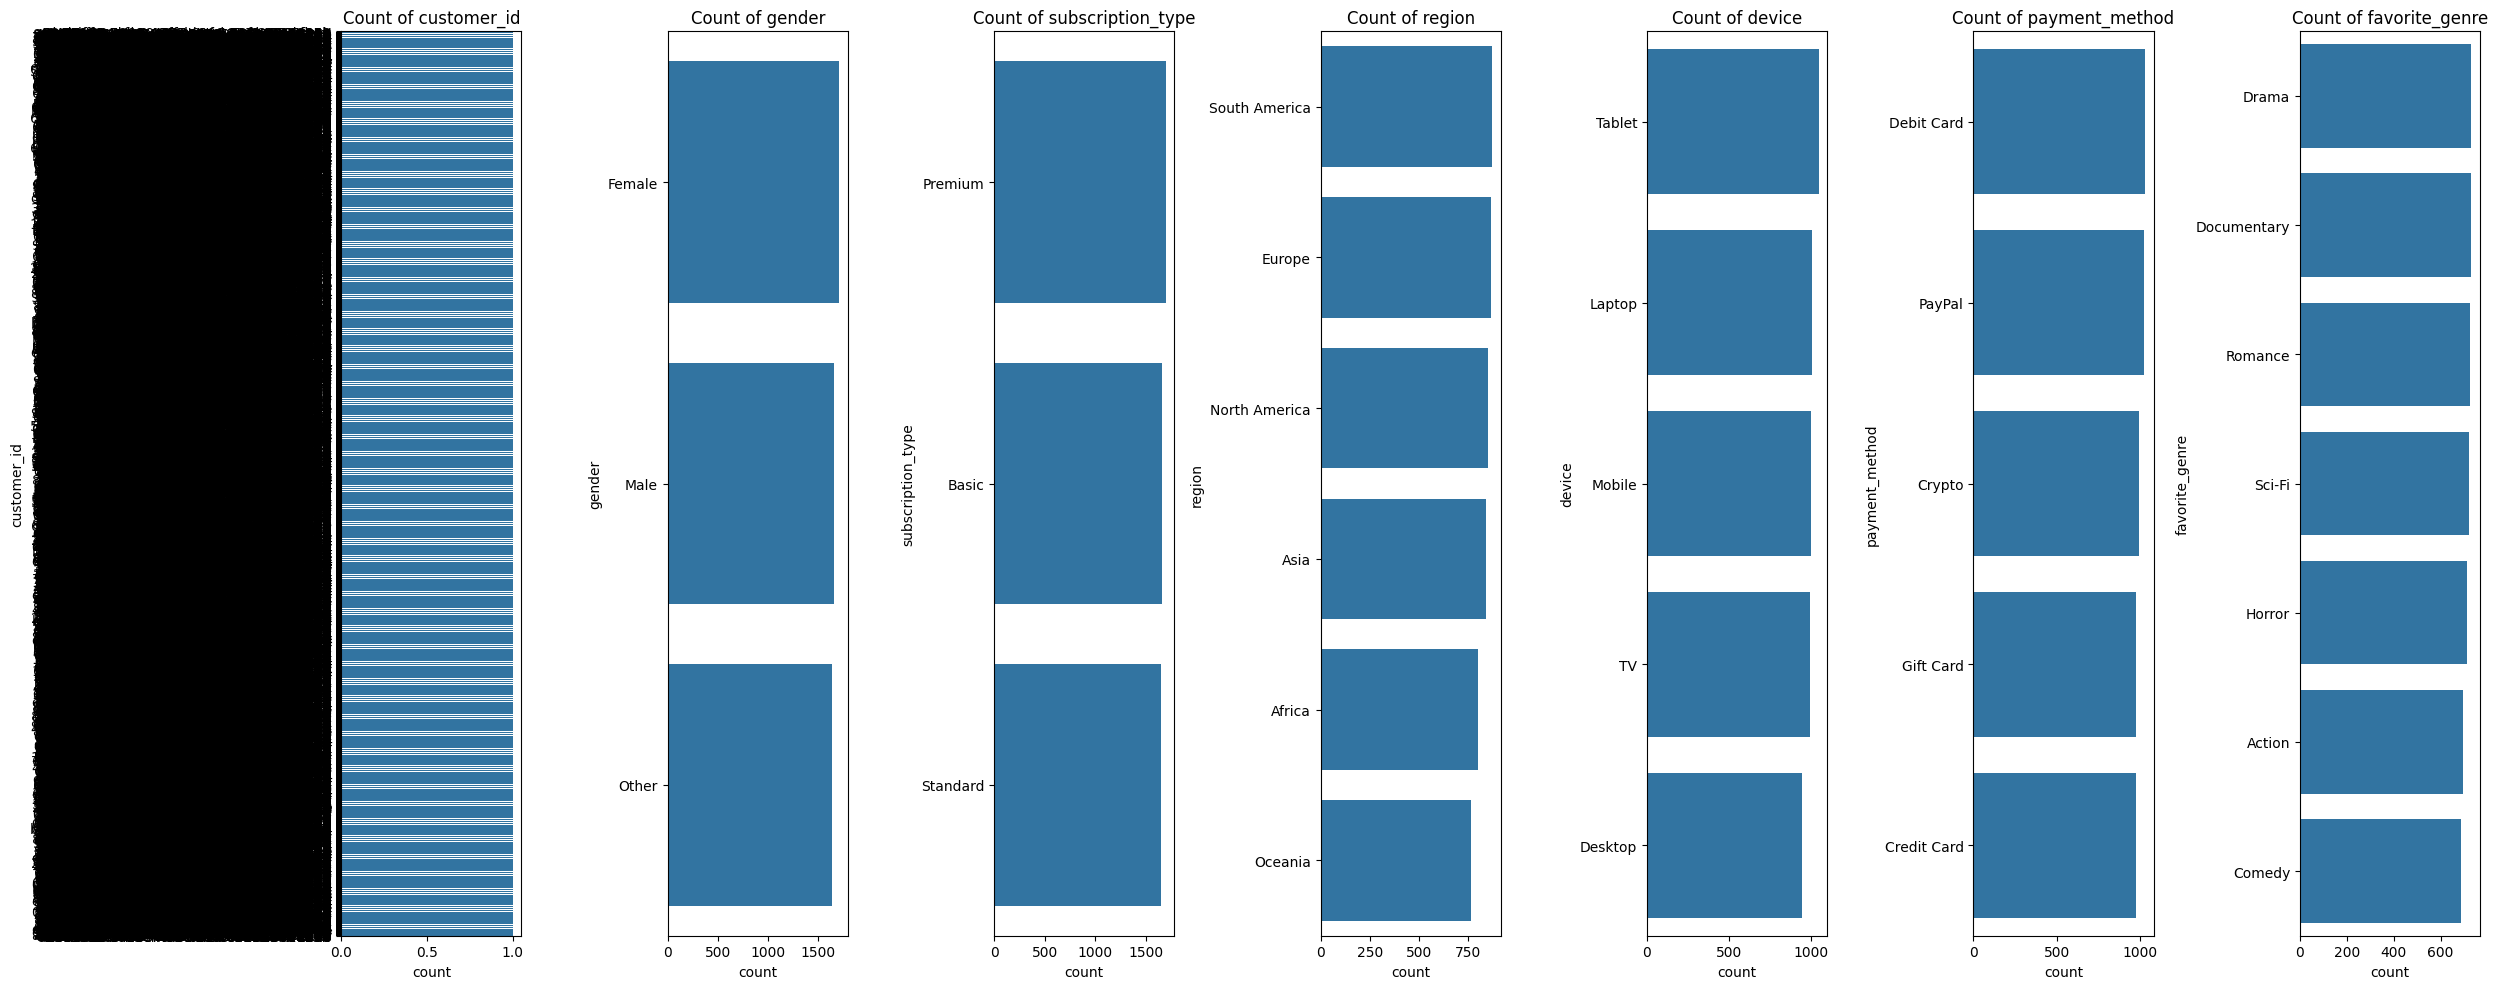

In [7]:
print('EDA for Numerical Features (data_num):')

eda_num = data.select_dtypes(exclude=object)
eda_cat = data.select_dtypes(include=object)

# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(eda_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=eda_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(eda_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(25, 10))
for i, column in enumerate(eda_cat.columns):
    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()

Target Variable

In [8]:
X = data.drop('churned', axis=1)
y = data['churned']

Train test split

In [9]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)


In [10]:
data_num = X.select_dtypes(exclude= object)
data_cat = X.select_dtypes(include= object)

In [11]:
data_num.head()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day
0,51,14.73,29,8.99,1,0.49
1,47,0.70,19,13.99,5,0.03
2,27,16.32,10,13.99,2,1.48
3,53,4.51,12,17.99,2,0.35
4,56,1.89,13,13.99,2,0.13


Scaling

In [12]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Apply StandardScaler to selected numerical feature columns
X_train_num = pd.DataFrame(
    std_scaler.fit_transform(X_train[data_num.columns]),
    columns=data_num.columns,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    std_scaler.transform(X_test[data_num.columns]),   # transform only — no fit
    columns=data_num.columns,
    index=X_test.index
)
#end

One Hot Encoding

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Extract categorical column names from data_cat, excluding 'customer_id'
# Use X_raw.select_dtypes(include=object) to get the original categorical columns, as data_cat was derived from the full X
categorical_cols = [col for col in X.select_dtypes(include=object).columns.tolist() if col != 'customer_id']

# Fit OneHotEncoder on X_train_raw's categorical features and transform both train and test
X_train_cat_enc = pd.DataFrame(
    ohe.fit_transform(X_train[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_train.index
)

X_test_cat_enc = pd.DataFrame(
    ohe.transform(X_test[categorical_cols]),
    columns=ohe.get_feature_names_out(categorical_cols),
    index=X_test.index
)

print("Encoded training categorical features shape:", X_train_cat_enc.shape)
print("Encoded test categorical features shape:", X_test_cat_enc.shape)
X_train_cat_enc.head()

Encoded training categorical features shape: (4000, 23)
Encoded test categorical features shape: (1000, 23)


,gender_Male,gender_Other,subscription_type_Premium,subscription_type_Standard,region_Asia,region_Europe,region_North America,region_Oceania,region_South America,device_Laptop,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
2008,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3404,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3165,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2408,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3975,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [15]:
X_train = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_test = pd.concat([X_test_num, X_test_cat_enc], axis=1)

Smoting

In [16]:
!pip install imblearn

Smote for highly unbalanced class. There is a a lot of class balance here aat 50:50

In [30]:
'''from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=10,
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())'''

'from imblearn.over_sampling import SMOTE\nfrom collections import Counter\n\nsmote = SMOTE(\n    sampling_strategy=\'auto\',\n    k_neighbors=10,\n)\n\nX_train_res, y_train_res = smote.fit_resample(X_train, y_train)\n\nprint("Original data:")\nprint(pd.Series(y).value_counts())\nprint()\nprint("Training data:")\nprint(pd.Series(y_train_res).value_counts())\nprint()\nprint("Testing data:")\nprint(pd.Series(y_test).value_counts())'

PCA is removed also beccause the class are balanced

In [18]:
'''from sklearn.decomposition import PCA

pca = PCA(n_components=22)

X_train_pca = pd.DataFrame(
    pca.fit_transform(X_train_res)
)
X_test_pca  = pd.DataFrame(
     pca.transform(X_test)
 )'''

Model

In [19]:
! pip install xgboost

In [20]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

models = [
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    DecisionTreeClassifier(max_leaf_nodes=3),
    DecisionTreeClassifier(max_leaf_nodes=10),
    DecisionTreeClassifier(max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1)
]

Cross Validation: StratifiedKFold

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Initialize Stratified KFold
kf = StratifiedKFold(n_splits=5, shuffle=True)

# Evaluate each model using Stratified KFold cross-validation
results = []

for model in models:
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='f1')
    cv_scores = pd.DataFrame(cv_scores)

    print(model)
    display(cv_scores.describe().T)
    print()
# end

RandomForestClassifier(max_leaf_nodes=3)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.900302,0.011483,0.881797,0.898246,0.902007,0.90953,0.909931



RandomForestClassifier(max_leaf_nodes=10)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.920829,0.015908,0.895417,0.919622,0.920482,0.933495,0.935129



RandomForestClassifier(max_leaf_nodes=30)


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.990304,0.007209,0.978882,0.98882,0.991283,0.995025,0.997512



AdaBoostClassifier(learning_rate=0.1, n_estimators=100)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.912936,0.008937,0.90411,0.908246,0.911188,0.913495,0.927639


RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       497
           1       0.84      0.95      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



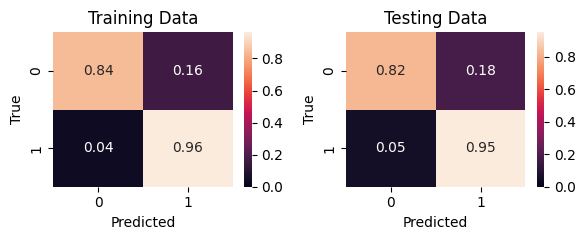

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       497
           1       0.88      0.94      0.91       503

    accuracy                           0.91      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.91      0.91      0.90      1000



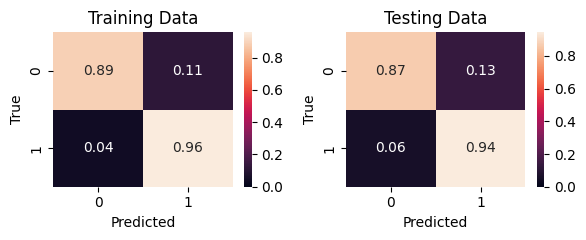

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       497
           1       0.96      0.96      0.96       503

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



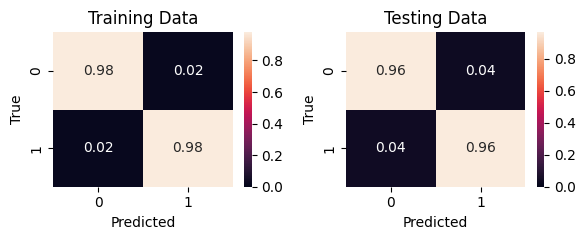

DecisionTreeClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       497
           1       0.78      0.95      0.86       503

    accuracy                           0.84      1000
   macro avg       0.86      0.84      0.84      1000
weighted avg       0.86      0.84      0.84      1000



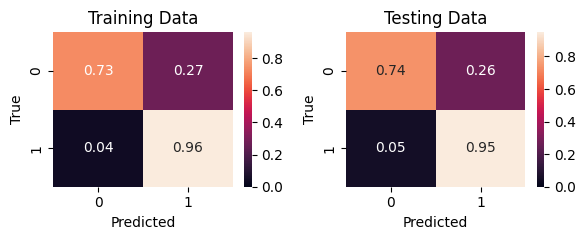

DecisionTreeClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       497
           1       0.90      0.93      0.91       503

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



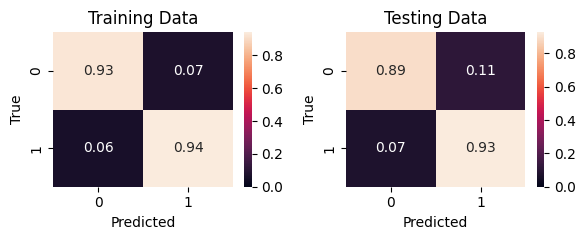

DecisionTreeClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       497
           1       0.99      0.97      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



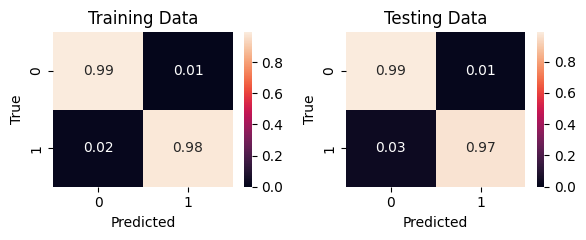

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       497
           1       0.95      0.97      0.96       503

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



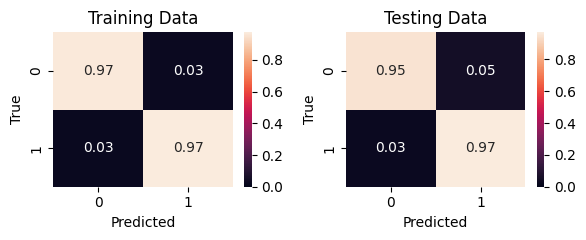

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       497
           1       0.99      0.98      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



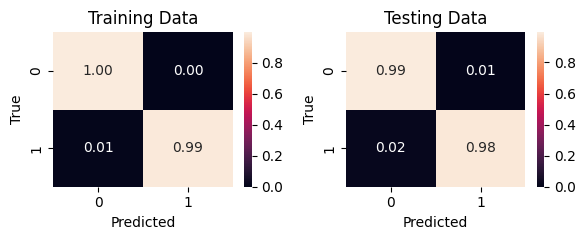

GradientBoostingClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       497
           1       0.99      0.98      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



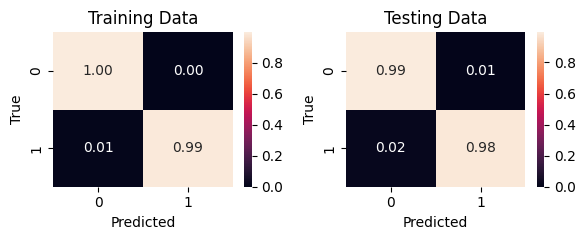

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=3, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0

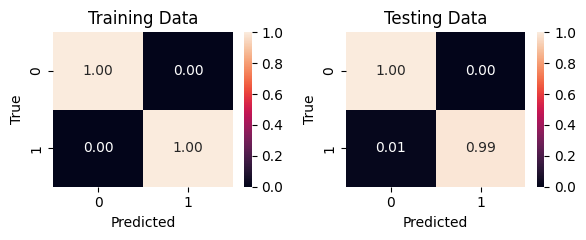

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=10, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      

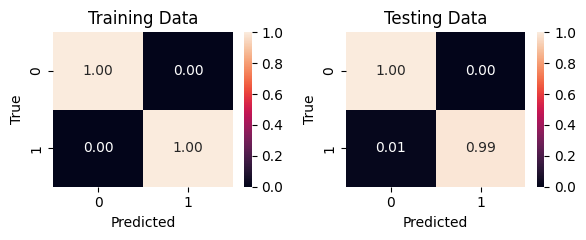

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaf_nodes=30, max_leaves=None, min_child_weight=None,
              missing=nan, monotone_constraints=None, multi_strategy=None,
              n_estimators=100, n_jobs=None, ...)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      

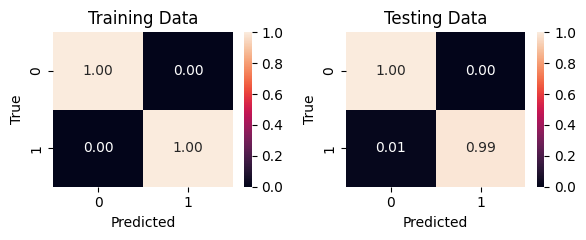

AdaBoostClassifier(learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       497
           1       0.85      0.98      0.91       503

    accuracy                           0.90      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.91      0.90      0.90      1000



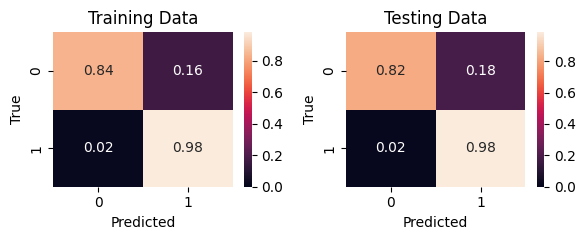

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()
        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()
    # end

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end


In [24]:
!pip install mlflow

  Using cached mlflow-3.14.0-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.14.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.5-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-48.0.1-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (4.3 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached sqlalchemy-2.0.51-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached databricks_sdk-0.119.0-py3-none-any.whl.metadata (43 kB)
  Using cached fastapi-0.138.2-py3-none-any.whl.metadata (26 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl

Evaluation Metrics

In [25]:
'''from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, average_precision_score, roc_auc_score, matthews_corrcoef
import mlflow
import mlflow.sklearn
import mlflow.xgboost

results = []

for i, m in enumerate(models):
    with mlflow.start_run(run_name=f"Model_{i+1}_{m.__class__.__name__}"):
        m.fit(X_train_res, y_train_res)
        y_train_pred = m.predict(X_train_res)
        y_test_pred = m.predict(X_test)

        # Calculate y_prob for the current model within the loop
        y_prob = m.predict_proba(X_test)[:, 1]

        auprc = average_precision_score(y_test, y_prob)
        auroc = roc_auc_score(y_test, y_prob)
        mcc   = matthews_corrcoef(y_test, y_test_pred)
        f1    = f1_score(y_test, y_test_pred)
        name  = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

        results.append({
            'Model': name,
            'AUPRC': auprc,
            'AUROC': auroc,
            'MCC':   mcc,
            'F1':    f1,
        })

        # Log metrics to MLflow
        mlflow.log_metrics({
            "auprc": auprc,
            "auroc": auroc,
            "mcc": mcc,
            "f1_score": f1
        })

        # Log parameters (e.g., max_leaf_nodes for tree-based models)
        if hasattr(m, 'max_leaf_nodes'):
            mlflow.log_param("max_leaf_nodes", m.max_leaf_nodes)
        if hasattr(m, 'n_estimators'):
            mlflow.log_param("n_estimators", m.n_estimators)
        if hasattr(m, 'learning_rate'):
            mlflow.log_param("learning_rate", m.learning_rate)

        # Log the model
        if isinstance(m, xgb.XGBClassifier):
            mlflow.xgboost.log_model(m, "model")
        else:
            mlflow.sklearn.log_model(m, "model")


        print(f"\n{'='*60}")

        print(m)
        print(classification_report(y_test, y_test_pred))

        # Compute confusion matrices
        conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
        conf_matrix_test = confusion_matrix(y_test, y_test_pred)

        # Create subplots for side-by-side visualization
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

        # Plot confusion matrix for training data
        sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0], cmap='nipy_spectral')
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("True")
        axes[0].set_title("Training Data")

        # Plot confusion matrix for test data
        sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1], cmap='nipy_spectral')
        axes[1].set_xlabel("Predicted")
        axes[1].set_ylabel("True")
        axes[1].set_title("Testing Data")

        # Show the plots
        plt.tight_layout()
        plt.show()

# --- Model comparison table ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by AUPRC) ===")
print(results_df.to_string(index=False))'''

'from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, average_precision_score, roc_auc_score, matthews_corrcoef\nimport mlflow\nimport mlflow.sklearn\nimport mlflow.xgboost\n\nresults = []\n\nfor i, m in enumerate(models):\n    with mlflow.start_run(run_name=f"Model_{i+1}_{m.__class__.__name__}"):\n        m.fit(X_train_res, y_train_res)\n        y_train_pred = m.predict(X_train_res)\n        y_test_pred = m.predict(X_test)\n\n        # Calculate y_prob for the current model within the loop\n        y_prob = m.predict_proba(X_test)[:, 1]\n\n        auprc = average_precision_score(y_test, y_prob)\n        auroc = roc_auc_score(y_test, y_prob)\n        mcc   = matthews_corrcoef(y_test, y_test_pred)\n        f1    = f1_score(y_test, y_test_pred)\n        name  = f"{m.__class__.__name__}(leaves={getattr(m, \'max_leaf_nodes\', \'N/A\')})"\n\n        results.append({\n            \'Model\': name,\n            \'AUPRC\':

AUPRC and AUROC

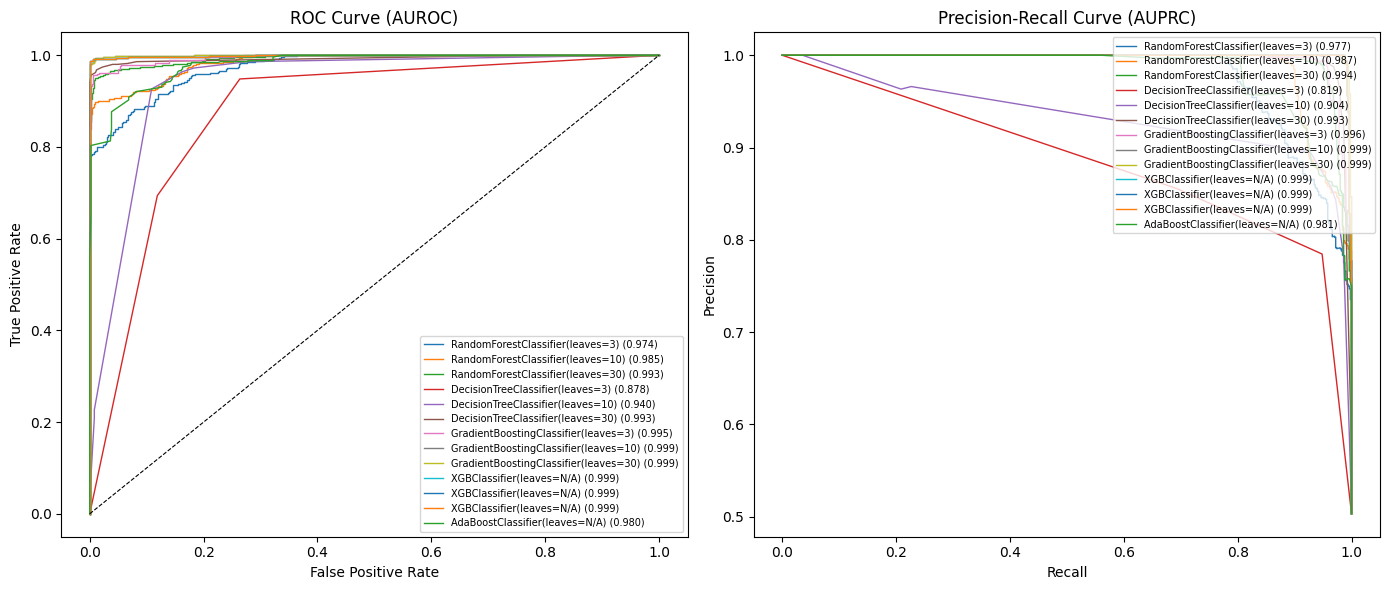

In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, matthews_corrcoef

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for m in models:
    y_prob = m.predict_proba(X_test)[:, 1]
    name = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', 'N/A')})"

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})", linewidth=1)

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} ({ap:.3f})", linewidth=1)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve (AUROC)')
axes[0].legend(fontsize=7, loc='lower right')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve (AUPRC)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[9] # Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.9989822628681234
AUROC: 0.9987599553583928


In [28]:
!pip install shap

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:03:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_leaf_nodes" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


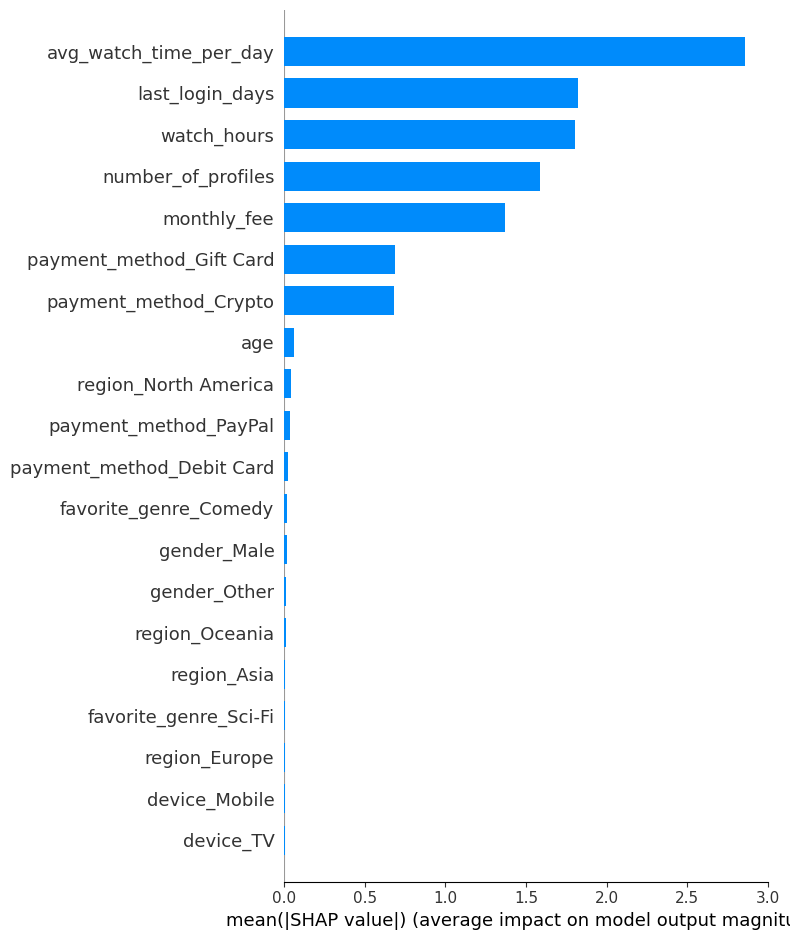

In [31]:
import shap

# Choose one of the trained models for explanation (e.g., the first XGBoost model)
# model_to_explain = models[9] # This is xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3)
# Or, if you want to use the best performing model from your MLflow run, you would select it here.

# Let's refit the chosen model just to be safe, as the `models` list might not contain fitted versions
model_to_explain = models[9]
model_to_explain.fit(X_train, y_train)

# Create a SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary plot (Feature Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# You can also get a more detailed summary plot
# shap.summary_plot(shap_values, X_test)
